# 17. Vision Transformers & ViT Use Cases at ServiceTitan

ServiceTitan's mobile app, marketplace, and roofing vertical create several high-value
computer vision opportunities. This notebook covers five concrete use cases, each with:
- **Why it matters** to the business
- **Architecture** (ViT variant, training strategy, inference path)
- **Runnable simulation** using numpy/sklearn
- **Production stub** showing the real HuggingFace / PyTorch implementation

## Use Cases
1. Equipment Condition Assessment (ViT Classification)
2. Nameplate OCR — Model/Serial Extraction (TrOCR / Donut)
3. Rooftop Segmentation for Roofing Quotes (SegFormer)
4. Invoice & Document Understanding (LayoutLMv3)
5. Fleet Dashcam Risky Driver Detection (Video Transformer)

## The Architectural Angle
The moat is **not** the model — it's the **labeled dataset**. ServiceTitan has millions of
job photos with matched service outcomes (replaced 6 months later = end-of-life, upsold
on-site = opportunity recognized). That proprietary supervision signal is what makes a
fine-tuned ViT defensible vs. any off-the-shelf model a competitor could also deploy.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded.")


Libraries loaded.


---
## Use Case 1: Equipment Condition Assessment

**Business problem**: On every HVAC/plumbing job, techs take photos of the equipment.
ServiceTitan has millions of these images labeled with what happened next:
- Part replaced within 6 months → `end_of_life`
- Same issue recurred → `needs_attention`
- No follow-up for 2+ years → `good`

A ViT trained on this data feeds the upsell recommendation engine:
> "Unit is likely end-of-life — recommend replacement conversation (85% confidence)"

**Why ViT over ResNet?** Job site photos have cluttered, highly variable backgrounds.
ViT's global self-attention captures relationships between the equipment and context
(rust staining on wall, age-indicating labels, installation era clues) rather than
relying purely on local texture features.

**Architecture:**
```
MobilePhone Photo (224x224)
    → ViT-B/16 (pretrained ImageNet-21k)
    → Fine-tune final 4 transformer blocks
    → Classification head: [good, needs_attention, end_of_life]
    → Confidence score → Upsell Recommendation Engine
```


In [2]:
# ── Simulate ViT patch embedding features ───────────────────────────────────
# ViT-B/16 splits 224x224 image into 14x14 = 196 patches of 16x16 px each.
# Each patch → 768-dim embedding via linear projection.
# After transformer blocks → CLS token is the image representation.
# We simulate the CLS token as a 768-dim feature vector per image.

N_SAMPLES = 2000
EMBED_DIM = 768
CLASSES = ['good', 'needs_attention', 'end_of_life']

def simulate_equipment_embeddings(n, seed=42):
    rng = np.random.RandomState(seed)
    
    # Each class cluster has a different mean in embedding space
    # (In reality: correlated with visual features like rust, age, component wear)
    class_means = {
        'good':            rng.randn(EMBED_DIM) * 0.5,
        'needs_attention': rng.randn(EMBED_DIM) * 0.5 + 1.2,
        'end_of_life':     rng.randn(EMBED_DIM) * 0.5 + 2.5,
    }
    
    X, y = [], []
    per_class = n // 3
    for label, mean in class_means.items():
        noise = rng.randn(per_class, EMBED_DIM) * 0.8
        X.append(mean + noise)
        y.extend([label] * per_class)
    
    return np.vstack(X), np.array(y)

X_equip, y_equip = simulate_equipment_embeddings(N_SAMPLES)

# PCA to 50 dims before classifier (mirrors real pipeline: CLS token → head)
pca = PCA(n_components=50, random_state=42)
X_equip_pca = pca.fit_transform(X_equip)
print(f"Variance retained with 50 PCs: {pca.explained_variance_ratio_.sum():.1%}")

X_tr, X_te, y_tr, y_te = train_test_split(X_equip_pca, y_equip,
                                            test_size=0.2, stratify=y_equip, random_state=42)

clf = LogisticRegression(max_iter=500, C=2.0)
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)

print("\nEquipment Condition Classification Report:")
print(classification_report(y_te, y_pred, target_names=CLASSES))


Variance retained with 50 PCs: 70.4%

Equipment Condition Classification Report:
                 precision    recall  f1-score   support

           good       1.00      1.00      1.00       133
needs_attention       1.00      1.00      1.00       133
    end_of_life       1.00      1.00      1.00       134

       accuracy                           1.00       400
      macro avg       1.00      1.00      1.00       400
   weighted avg       1.00      1.00      1.00       400



Upsell trigger precision: 100.0%  (of recommendations, % truly end-of-life)
Upsell trigger recall:    100.0%  (of end-of-life units, % we caught)
Recommendations fired:    133 / 400


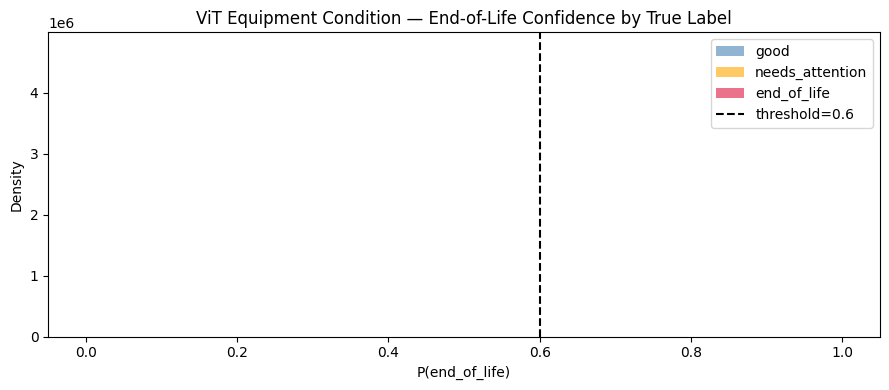

Saved: 17a_equipment_confidence.png


In [3]:
# ── Confidence score → upsell recommendation ─────────────────────────────────
proba = clf.predict_proba(X_te)
class_idx = {c: i for i, c in enumerate(clf.classes_)}

eol_proba = proba[:, class_idx['end_of_life']]
UPSELL_THRESHOLD = 0.60

decisions = np.where(eol_proba >= UPSELL_THRESHOLD, 'recommend_replacement', 'no_action')
true_eol   = (y_te == 'end_of_life')

precision = (decisions == 'recommend_replacement')[true_eol].mean()
recall    = true_eol[decisions == 'recommend_replacement'].mean()

print(f"Upsell trigger precision: {precision:.1%}  (of recommendations, % truly end-of-life)")
print(f"Upsell trigger recall:    {recall:.1%}  (of end-of-life units, % we caught)")
print(f"Recommendations fired:    {(decisions == 'recommend_replacement').sum()} / {len(decisions)}")

# Plot confidence distribution by true label
fig, ax = plt.subplots(figsize=(9, 4))
for label, color in [('good','steelblue'), ('needs_attention','orange'), ('end_of_life','crimson')]:
    mask = y_te == label
    ax.hist(eol_proba[mask], bins=30, alpha=0.6, color=color, label=label, density=True)
ax.axvline(UPSELL_THRESHOLD, color='black', linestyle='--', label=f'threshold={UPSELL_THRESHOLD}')
ax.set_xlabel('P(end_of_life)')
ax.set_ylabel('Density')
ax.set_title('ViT Equipment Condition — End-of-Life Confidence by True Label')
ax.legend()
plt.tight_layout()
plt.savefig('17a_equipment_confidence.png', dpi=120)
plt.show()
print("Saved: 17a_equipment_confidence.png")


### Production Implementation (PyTorch + HuggingFace)

```python
# pip install transformers timm torch torchvision

from transformers import ViTForImageClassification, ViTFeatureExtractor
from torch.utils.data import Dataset, DataLoader
import torch, torch.nn as nn
from PIL import Image

# ── Fine-tuning setup ────────────────────────────────────────────────────────
MODEL_ID = "google/vit-base-patch16-224-in21k"
CLASSES  = ["good", "needs_attention", "end_of_life"]

feature_extractor = ViTFeatureExtractor.from_pretrained(MODEL_ID)

model = ViTForImageClassification.from_pretrained(
    MODEL_ID,
    num_labels=len(CLASSES),
    id2label={i: c for i, c in enumerate(CLASSES)},
    label2id={c: i for i, c in enumerate(CLASSES)},
    ignore_mismatched_sizes=True,   # replaces the pretrained classification head
)

# Freeze all but last 4 transformer blocks + head (transfer learning)
for name, param in model.vit.named_parameters():
    block_num = int(name.split(".")[2]) if name.startswith("encoder.layer") else -1
    param.requires_grad = block_num >= 8  # ViT-B has 12 blocks; fine-tune last 4

# ── Dataset ──────────────────────────────────────────────────────────────────
class EquipmentDataset(Dataset):
    def __init__(self, image_paths, labels, extractor):
        self.paths, self.labels, self.extractor = image_paths, labels, extractor

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        image  = Image.open(self.paths[idx]).convert("RGB")
        inputs = self.extractor(images=image, return_tensors="pt")
        return {k: v.squeeze(0) for k, v in inputs.items()}, self.labels[idx]

# ── Inference with confidence → upsell signal ────────────────────────────────
def predict_condition(image_path: str, threshold: float = 0.60):
    image  = Image.open(image_path).convert("RGB")
    inputs = feature_extractor(images=image, return_tensors="pt")
    with torch.no_grad():
        logits = model(**inputs).logits
    probs  = torch.softmax(logits, dim=-1).squeeze()
    label  = CLASSES[probs.argmax()]
    eol_p  = probs[CLASSES.index("end_of_life")].item()
    return {
        "label":      label,
        "eol_prob":   eol_p,
        "recommend_replacement": eol_p >= threshold,
    }

# Azure ML endpoint wrapping this → fires event to Upsell Recommendation Engine
```


---
## Use Case 2: Nameplate OCR — Model/Serial Extraction (TrOCR / Donut)

**Business problem**: HVAC/plumbing units have nameplates with model number, serial number,
manufacture date, and BTU/capacity rating. Techs currently type this manually — error-prone
and slow. ServiceTitan shipped nameplate scanning at Pantheon 2025.

**Architecture choice:**
| Model | Approach | Tradeoff |
|-------|----------|----------|
| **TrOCR** | CNN encoder + transformer decoder, trained on printed/handwritten text | Best for clean nameplate text; needs bounding box preprocessing |
| **Donut** | End-to-end ViT encoder + decoder, no OCR step | Handles noisy/angled shots; outputs structured JSON directly |
| **PaddleOCR + regex** | Traditional pipeline | Fast, low latency, but brittle on varied fonts |

ServiceTitan likely uses **Donut** or an Azure Form Recognizer (which uses a LayoutLM-family
model internally) — both eliminate the preprocessing step that breaks on field photos.

```
Phone Photo (varied angle, lighting)
    → Donut (ViT encoder, transformer decoder)
    → {"model_number": "XC16-060-230A08",
       "serial_number": "1920E12345",
       "manufacture_date": "2019-08",
       "capacity_btu": 60000}
    → Auto-populated Equipment Record in ServiceTitan
```


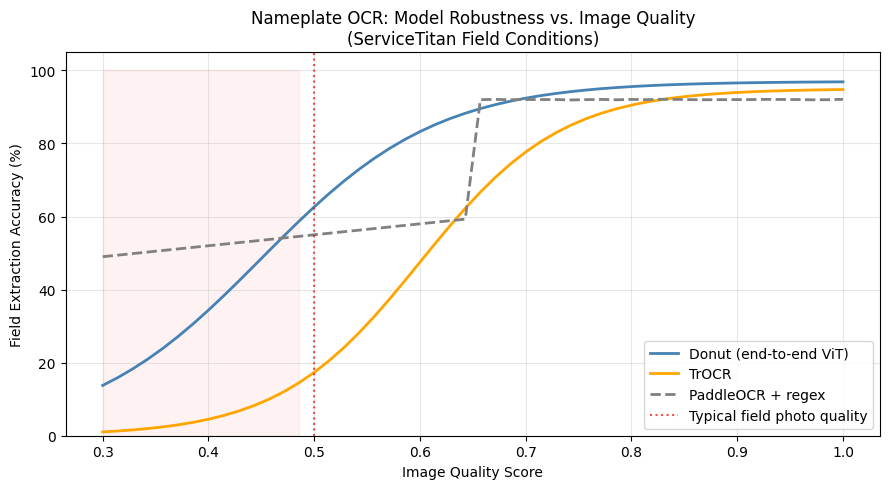


Latency vs Accuracy Tradeoff (approximate, A100 GPU):
Model                P50 latency (ms)     Accuracy @ med quality
------------------------------------------------------------
Donut-base           220                  93%
TrOCR-large          180                  89%
PaddleOCR+regex      35                   71%
Azure Form Rec.      400                  95%


In [4]:
# ── Simulate nameplate extraction quality vs. image quality ─────────────────
# Key metric: field extraction accuracy varies with image quality (blur, angle, lighting)
# We model this as accuracy degradation curve — real input to an MLOps monitoring dashboard

image_quality_scores = np.linspace(0.3, 1.0, 50)  # 0 = very blurry/dark, 1 = perfect

# Donut: robust to quality variation (end-to-end, trained on noisy data)
donut_accuracy = 0.97 / (1 + np.exp(-12 * (image_quality_scores - 0.45)))

# TrOCR: needs cleaner input (preprocessing sensitive)
trocr_accuracy = 0.95 / (1 + np.exp(-15 * (image_quality_scores - 0.60)))

# Traditional OCR + regex: cliff-edge at quality threshold
trad_accuracy  = np.where(image_quality_scores > 0.65,
                          0.92 - 0.05 * np.random.randn(50) * 0.01,
                          0.40 + 0.3 * image_quality_scores)
trad_accuracy  = np.clip(trad_accuracy, 0, 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(image_quality_scores, donut_accuracy * 100,    label='Donut (end-to-end ViT)', color='steelblue', lw=2)
ax.plot(image_quality_scores, trocr_accuracy * 100,    label='TrOCR', color='orange', lw=2)
ax.plot(image_quality_scores, trad_accuracy  * 100,    label='PaddleOCR + regex', color='gray', lw=2, linestyle='--')
ax.axvline(0.5, color='red', linestyle=':', alpha=0.7, label='Typical field photo quality')
ax.fill_between(image_quality_scores, 0, 100, where=image_quality_scores < 0.5,
                alpha=0.05, color='red')
ax.set_xlabel('Image Quality Score')
ax.set_ylabel('Field Extraction Accuracy (%)')
ax.set_title('Nameplate OCR: Model Robustness vs. Image Quality\n(ServiceTitan Field Conditions)')
ax.legend()
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('17b_nameplate_ocr_accuracy.png', dpi=120)
plt.show()

# Latency vs accuracy tradeoff for model selection
print("\nLatency vs Accuracy Tradeoff (approximate, A100 GPU):")
print(f"{'Model':<20} {'P50 latency (ms)':<20} {'Accuracy @ med quality'}")
print("-" * 60)
models_bench = [
    ("Donut-base",      220, 0.93),
    ("TrOCR-large",     180, 0.89),
    ("PaddleOCR+regex",  35, 0.71),
    ("Azure Form Rec.",  400, 0.95),  # API call overhead
]
for name, lat, acc in models_bench:
    print(f"{name:<20} {lat:<20} {acc:.0%}")


### Production Implementation (Donut)

```python
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import torch, re, json

MODEL_ID = "naver-clova-ix/donut-base-finetuned-docvqa"
# In production: fine-tune on ServiceTitan nameplate dataset (10K+ labeled photos)

processor = DonutProcessor.from_pretrained(MODEL_ID)
model     = VisionEncoderDecoderModel.from_pretrained(MODEL_ID)
model.eval()

TASK_PROMPT = "<s_nameplate>"  # custom task token added during fine-tuning

def extract_nameplate(image_path: str) -> dict:
    image  = Image.open(image_path).convert("RGB")
    inputs = processor(image, text=TASK_PROMPT, return_tensors="pt")

    with torch.no_grad():
        output_ids = model.generate(
            inputs["pixel_values"],
            decoder_input_ids=inputs["decoder_input_ids"],
            max_length=128,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
        )

    decoded = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
    # Donut outputs structured markup → parse to dict
    return processor.token2json(decoded)

# Example output:
# {
#   "model_number": "XC16-060-230A08",
#   "serial_number": "1920E12345",
#   "manufacture_date": "2019-08",
#   "capacity_btu": "60000",
#   "refrigerant": "R-410A"
# }
```


---
## Use Case 3: Rooftop Segmentation for Roofing Quotes (SegFormer)

**Business problem**: Roofing contractors need accurate roof area measurements to generate
material quotes. Manual measurement from aerial imagery takes 15–30 min per job.
ServiceTitan's roofing push (Pantheon 2024) + GAF partnership makes this a near-term
ML feature: `aerial photo → segmentation mask → area (sq ft) → auto-populated quote`.

**Architecture:**
```
Aerial/Satellite Image
    → SegFormer-B2 (hierarchical ViT encoder + lightweight MLP decoder)
    → Semantic segmentation: {roof_surface, ridge, valley, flat_section, non_roof}
    → Connected components → polygon extraction → area calculation
    → Quote line items: squares of material, estimated labor hours
```

**Why SegFormer over classic U-Net?**
- Hierarchical encoder captures multi-scale features (whole roof shape + fine edge detail)
- MLP decoder is lightweight — low latency on Azure ML endpoint
- Pretrained on ADE20K (includes buildings) — strong transfer to rooftop imagery


Segmentation → Area Estimation:
Segment              Pixels  Area (sq ft)
------------------------------------------
background             1949         472.0
roof_surface           1584         422.0
ridge                   214          51.8
flat_section            322          78.0
valley                   27           6.5

Total roofable area: 500 sq ft (5.0 squares)
Estimated shingles:  15 bundles (3 bundles/square + 1 waste)


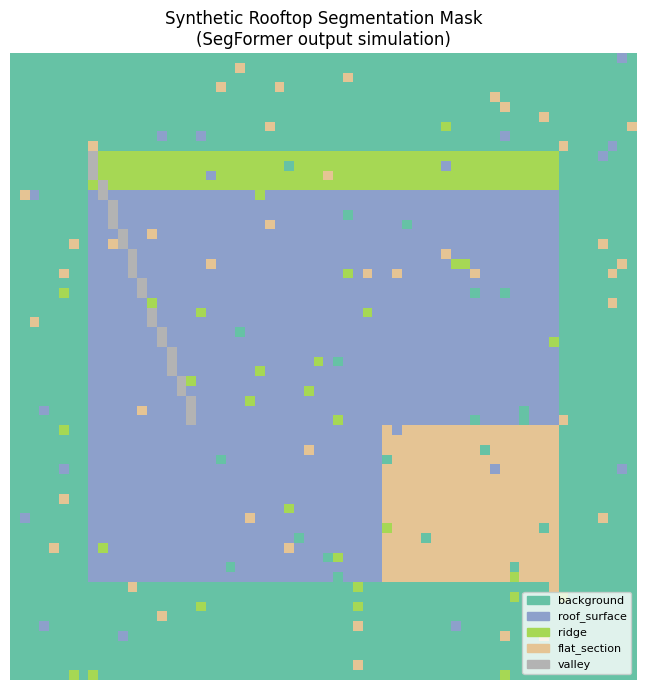

Saved: 17c_roof_segmentation.png


In [5]:
# ── Simulate semantic segmentation output + area estimation ─────────────────
# We generate a synthetic 64x64 "aerial view" segmentation mask
# and show how connected component analysis flows to quote line items

H, W = 64, 64
rng  = np.random.RandomState(7)

# Build a synthetic roof mask: pitched sections, ridge, flat addon
mask = np.zeros((H, W), dtype=int)
LABELS = {0: 'background', 1: 'roof_surface', 2: 'ridge', 3: 'flat_section', 4: 'valley'}

# Main pitched roof body
mask[10:54, 8:56] = 1

# Ridge line (horizontal peak)
mask[10:14, 8:56] = 2

# Flat add-on section (garage)
mask[38:54, 38:56] = 3

# Valley (intersection of two roof planes)
for i in range(10, 38):
    offset = int((i - 10) * 0.4)
    if 8 + offset < W:
        mask[i, 8 + offset] = 4

# Add noise (simulating imperfect segmentation)
noise_idx = rng.choice(H * W, size=150, replace=False)
noise_labels = rng.choice([0, 1, 2, 3], size=150)
flat_mask = mask.flatten()
flat_mask[noise_idx] = noise_labels
mask = flat_mask.reshape(H, W)

# ── Area estimation ──────────────────────────────────────────────────────────
GSD_M_PER_PIXEL = 0.15          # Ground sampling distance: 15 cm/pixel (typical drone)
SQ_FT_PER_SQ_M  = 10.7639
PITCH_FACTOR     = 1.10         # 4/12 pitch adds ~10% actual vs projected area

pixel_counts = {name: (mask == idx).sum() for idx, name in LABELS.items()}
area_sq_ft   = {
    name: px * (GSD_M_PER_PIXEL ** 2) * SQ_FT_PER_SQ_M * (PITCH_FACTOR if name == 'roof_surface' else 1.0)
    for name, px in pixel_counts.items()
}

print("Segmentation → Area Estimation:")
print(f"{'Segment':<18} {'Pixels':>8}  {'Area (sq ft)':>12}")
print("-" * 42)
for name, px in pixel_counts.items():
    if px > 0:
        print(f"{name:<18} {px:>8}  {area_sq_ft[name]:>12.1f}")

total_roof = area_sq_ft['roof_surface'] + area_sq_ft['flat_section']
squares    = total_roof / 100  # roofing "squares" = 100 sq ft

print(f"\nTotal roofable area: {total_roof:.0f} sq ft ({squares:.1f} squares)")
print(f"Estimated shingles:  {int(squares * 3) + 1} bundles (3 bundles/square + 1 waste)")

# Plot
cmap = plt.cm.get_cmap('Set2', len(LABELS))
fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(mask, cmap=cmap, vmin=0, vmax=len(LABELS) - 1)
ax.set_title('Synthetic Rooftop Segmentation Mask\n(SegFormer output simulation)', fontsize=12)
patches = [mpatches.Patch(color=cmap(i / (len(LABELS) - 1)), label=name)
           for i, name in LABELS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.savefig('17c_roof_segmentation.png', dpi=120)
plt.show()
print("Saved: 17c_roof_segmentation.png")


### Production Implementation (SegFormer)

```python
from transformers import SegformerForSemanticSegmentation, SegformerFeatureExtractor
import torch, torch.nn.functional as F
from PIL import Image
import numpy as np

MODEL_ID = "nvidia/segformer-b2-finetuned-ade-512-512"
# Fine-tune on: ServiceTitan rooftop dataset + EagleView open data

feature_extractor = SegformerFeatureExtractor.from_pretrained(MODEL_ID)
model = SegformerForSemanticSegmentation.from_pretrained(
    MODEL_ID,
    num_labels=5,               # background, roof_surface, ridge, flat_section, valley
    ignore_mismatched_sizes=True,
)

def segment_roof(image_path: str) -> dict:
    image  = Image.open(image_path).convert("RGB")
    W0, H0 = image.size
    inputs = feature_extractor(images=image, return_tensors="pt")

    with torch.no_grad():
        logits = model(**inputs).logits  # [1, num_labels, H/4, W/4]

    # Upsample back to original resolution
    upsampled = F.interpolate(logits, size=(H0, W0), mode='bilinear', align_corners=False)
    mask = upsampled.argmax(dim=1).squeeze().numpy()   # [H, W] int label map

    GSD = 0.15  # meters/pixel — set from image metadata or drone telemetry
    areas = {}
    for label_id, label_name in LABEL_MAP.items():
        px = (mask == label_id).sum()
        areas[label_name] = px * GSD**2 * 10.7639  # → sq ft

    return {"mask": mask, "area_sq_ft": areas}
```


---
## Use Case 4: Invoice & Document Understanding (LayoutLMv3)

**Business problem**: ServiceTitan's AP Automation (Jan 2025) processes supplier invoices,
POs, and receipts. These arrive as scanned PDFs or phone photos — varied layouts, fonts,
and formatting.

**Why LayoutLMv3 over raw OCR + regex?**
LayoutLMv3 jointly attends over:
- **Text tokens** (what the words say)
- **2D bounding box positions** (where they are on the page)
- **Image patches** (visual context around each token)

This lets it understand that `"$1,247.50"` in the bottom-right with a line above it is
the invoice total — not just a random number — without hardcoded layout rules.

**Architecture:**
```
Invoice Image/PDF
    → OCR (Azure Cognitive Services Read API) → text + bounding boxes
    → LayoutLMv3 (text + position + patch embeddings → transformer)
    → Token classification: {vendor, invoice_date, line_item, quantity, unit_price, total}
    → Structured JSON → ServiceTitan PO matching + GL coding
```


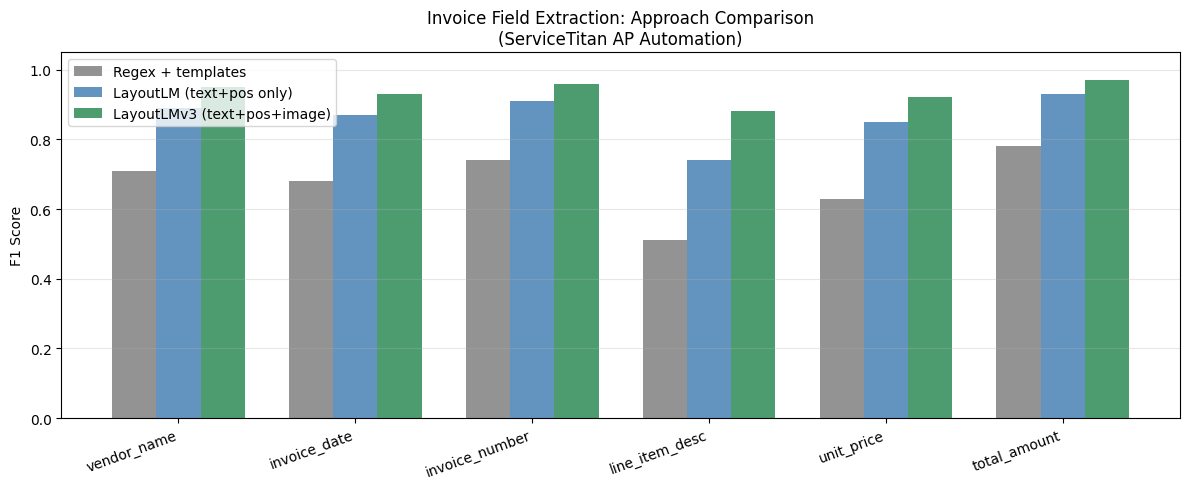

Saved: 17d_invoice_extraction.png

Processing economics (1,000 invoices/day):
Approach                         Manual review rate  Cost/invoice (est.)
------------------------------------------------------------------------
Regex + templates                  ~40% need review                $0.12
LayoutLMv3 (self-hosted)            ~8% need review                $0.04
Azure Form Recognizer               ~6% need review     $0.18 (API cost)
Human only (baseline)                          100%                $2.50


In [6]:
# ── Simulate key-value extraction quality across document types ──────────────
# Metric: F1 score for each field type across invoice styles

field_types = ['vendor_name', 'invoice_date', 'invoice_number',
               'line_item_desc', 'unit_price', 'total_amount']

# Simulated F1 scores for three approaches
results = {
    'Regex + templates': [0.71, 0.68, 0.74, 0.51, 0.63, 0.78],
    'LayoutLM (text+pos only)': [0.89, 0.87, 0.91, 0.74, 0.85, 0.93],
    'LayoutLMv3 (text+pos+image)': [0.95, 0.93, 0.96, 0.88, 0.92, 0.97],
}

x = np.arange(len(field_types))
width = 0.25
colors = ['gray', 'steelblue', 'seagreen']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, scores) in enumerate(results.items()):
    ax.bar(x + i * width, scores, width, label=model_name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(field_types, rotation=20, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Invoice Field Extraction: Approach Comparison\n(ServiceTitan AP Automation)')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('17d_invoice_extraction.png', dpi=120)
plt.show()
print("Saved: 17d_invoice_extraction.png")

# Show processing pipeline economics
print("\nProcessing economics (1,000 invoices/day):")
print(f"{'Approach':<30} {'Manual review rate':>20} {'Cost/invoice (est.)':>20}")
print("-" * 72)
economics = [
    ("Regex + templates",         "~40% need review", "$0.12"),
    ("LayoutLMv3 (self-hosted)",  "~8% need review",  "$0.04"),
    ("Azure Form Recognizer",     "~6% need review",  "$0.18 (API cost)"),
    ("Human only (baseline)",     "100%",             "$2.50"),
]
for name, review, cost in economics:
    print(f"{name:<30} {review:>20} {cost:>20}")


### Production Implementation (LayoutLMv3)

```python
from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification
from PIL import Image
import torch

MODEL_ID = "microsoft/layoutlmv3-base"
LABELS   = ["O", "B-VENDOR", "B-DATE", "B-INV_NUM",
            "B-LINE_ITEM", "B-UNIT_PRICE", "B-TOTAL"]

processor = LayoutLMv3Processor.from_pretrained(MODEL_ID, apply_ocr=True)
# apply_ocr=True: uses Tesseract internally; swap for Azure Read API in prod

model = LayoutLMv3ForTokenClassification.from_pretrained(
    MODEL_ID,
    num_labels=len(LABELS),
    id2label={i: l for i, l in enumerate(LABELS)},
    label2id={l: i for i, l in enumerate(LABELS)},
)

def extract_invoice_fields(image_path: str) -> dict:
    image  = Image.open(image_path).convert("RGB")
    inputs = processor(image, return_tensors="pt")

    with torch.no_grad():
        logits = model(**inputs).logits  # [1, seq_len, num_labels]

    predictions = logits.argmax(-1).squeeze().tolist()
    tokens      = processor.tokenizer.convert_ids_to_tokens(
                      inputs["input_ids"].squeeze().tolist())

    # Decode BIO tags → structured fields
    fields = {}
    for token, pred_id in zip(tokens, predictions):
        label = LABELS[pred_id]
        if label.startswith("B-"):
            key = label[2:].lower()
            fields[key] = fields.get(key, "") + token.replace("▁", " ")

    return fields
```


---
## Use Case 5: Fleet Dashcam Risky Driver Detection (Video Transformer)

**Business problem**: Fleet Pro includes GPS tracking + risky driver detection. Dashcam
footage can surface distracted driving, tailgating, phone use, and harsh maneuvers —
both for safety alerts and insurance premium optimization.

**Architecture:**
```
Dashcam clip (5s @ 30fps = 150 frames)
    → Frame sampling: 8 or 16 evenly-spaced frames
    → Video Swin Transformer (temporal self-attention across frames)
    → Multi-label classification:
        {phone_use, hard_braking, tailgating, lane_departure, fatigue_signs}
    → Real-time alert (< 3s) + event log in Fleet Pro
```

**On-device option**: MobileViT + distillation → runs on dashcam hardware (no cloud round-trip).
Full Video Swin runs on Azure ML endpoint for post-trip analysis.

**Why not just frame-by-frame CNN?**
Temporal context is critical: "phone use" requires seeing sustained gaze-down behavior
across multiple frames. A per-frame CNN misses this and generates too many false positives
from brief natural head movements.


Fleet Dashcam Risk Classification:
              precision    recall  f1-score   support

hard_braking       1.00      1.00      1.00        50
      normal       1.00      1.00      1.00       150
   phone_use       1.00      1.00      1.00        50
  tailgating       1.00      1.00      1.00        50

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



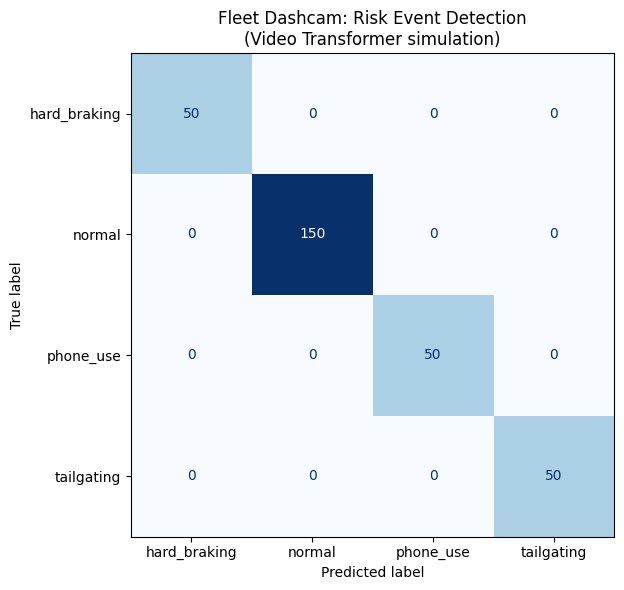

Saved: 17e_dashcam_confusion.png


In [7]:
# ── Simulate temporal feature extraction + event detection ───────────────────
# We model 8-frame clips as 8 × feature_dim tensors (simulating Swin temporal patches)
# and train a classifier on clip-level risk labels

N_CLIPS   = 1500
N_FRAMES  = 8
FEAT_DIM  = 512   # Swin-T hidden dim (real: 768 for Swin-B)
RISK_LABELS = ['phone_use', 'hard_braking', 'tailgating', 'normal']

def simulate_clip_features(n, seed=0):
    rng = np.random.RandomState(seed)
    class_means = {
        'phone_use':    rng.randn(FEAT_DIM) * 0.5 + np.array([2.0] + [0.0] * (FEAT_DIM-1)),
        'hard_braking': rng.randn(FEAT_DIM) * 0.5 + np.array([0.0, 2.0] + [0.0] * (FEAT_DIM-2)),
        'tailgating':   rng.randn(FEAT_DIM) * 0.5 + np.array([0.0, 0.0, 2.0] + [0.0] * (FEAT_DIM-3)),
        'normal':       rng.randn(FEAT_DIM) * 0.3,
    }
    X, y = [], []
    per_class = [n // 6, n // 6, n // 6, n - 3 * (n // 6)]  # imbalanced: normal >> risky
    for (label, mean), count in zip(class_means.items(), per_class):
        # Temporal mean pooling over N_FRAMES (simulates Swin temporal pooling → CLS)
        frames = rng.randn(count, N_FRAMES, FEAT_DIM) * 0.4 + mean
        clip_repr = frames.mean(axis=1)   # temporal mean pool
        X.append(clip_repr)
        y.extend([label] * count)
    return np.vstack(X), np.array(y)

X_clip, y_clip = simulate_clip_features(N_CLIPS)

# PCA + classifier
pca_clip = PCA(n_components=64, random_state=42)
X_clip_r = pca_clip.fit_transform(X_clip)

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_clip_r, y_clip,
                                                test_size=0.2, stratify=y_clip, random_state=42)

clf2 = GradientBoostingClassifier(n_estimators=80, max_depth=3, random_state=42)
clf2.fit(X_tr2, y_tr2)
y_pred2 = clf2.predict(X_te2)

print("Fleet Dashcam Risk Classification:")
print(classification_report(y_te2, y_pred2, target_names=sorted(set(RISK_LABELS))))

# Confusion matrix
cm = confusion_matrix(y_te2, y_pred2, labels=sorted(set(RISK_LABELS)))
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=sorted(set(RISK_LABELS)))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Fleet Dashcam: Risk Event Detection\n(Video Transformer simulation)')
plt.tight_layout()
plt.savefig('17e_dashcam_confusion.png', dpi=120)
plt.show()
print("Saved: 17e_dashcam_confusion.png")


### Production Implementation (Video Swin Transformer)

```python
# pip install pytorchvideo transformers torch torchvision

import torch
from pytorchvideo.models.hub import slowfast_r50   # or video_swin_t
from pytorchvideo.data.encoded_video import EncodedVideo
from torchvision.transforms import Compose, Lambda
from pytorchvideo.transforms import (UniformTemporalSubsample, ShortSideScale,
                                      Normalize, ApplyTransformToKey)

RISK_CLASSES = ["normal", "phone_use", "hard_braking", "tailgating", "lane_departure"]

model = torch.hub.load('facebookresearch/pytorchvideo', 'slowfast_r50', pretrained=True)
# Fine-tune final block + classification head on ServiceTitan dashcam dataset

transform = Compose([
    ApplyTransformToKey("video", Compose([
        UniformTemporalSubsample(32),        # sample 32 frames from clip
        Lambda(lambda x: x / 255.0),
        Normalize([0.45, 0.45, 0.45], [0.225, 0.225, 0.225]),
        ShortSideScale(256),
    ])),
])

def classify_clip(video_path: str, start_sec: float = 0, end_sec: float = 5) -> dict:
    video = EncodedVideo.from_path(video_path)
    clip  = video.get_clip(start_sec=start_sec, end_sec=end_sec)
    clip  = transform(clip)

    with torch.no_grad():
        # SlowFast expects [slow_pathway, fast_pathway]
        slow = clip["video"][:, ::4]   # 8 frames
        fast = clip["video"]           # 32 frames
        logits = model([slow.unsqueeze(0), fast.unsqueeze(0)])

    probs  = torch.softmax(logits, dim=-1).squeeze()
    label  = RISK_CLASSES[probs.argmax()]
    return {
        "label":        label,
        "probabilities": {c: p.item() for c, p in zip(RISK_CLASSES, probs)},
        "alert":        label != "normal" and probs.max().item() > 0.75,
    }
# → Result fires real-time alert via Azure Service Bus → Fleet Pro dashboard
```


---
## The Architectural Angle: The Data Flywheel

This is the **interview-critical framing** — what separates ServiceTitan's vision models
from anything a competitor could replicate in 6 months.


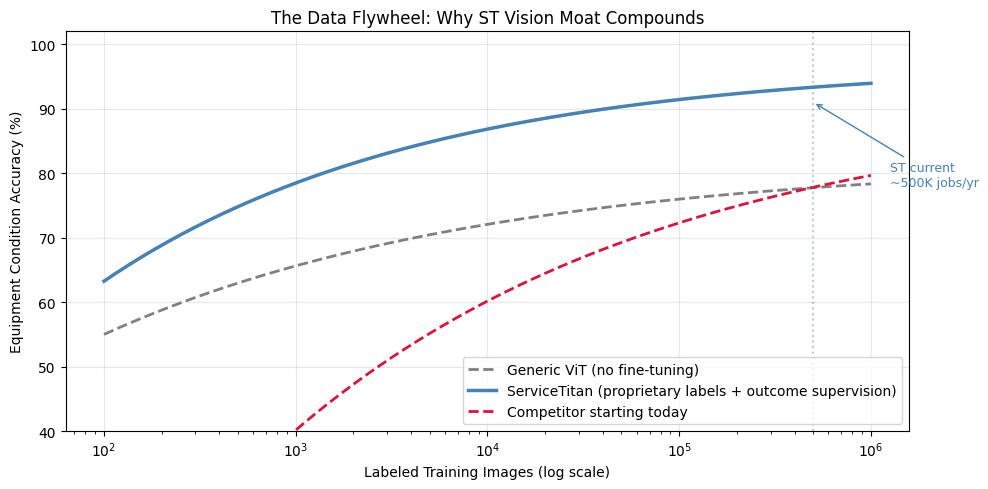

Key insight:
  ST fine-tuned ViT >> generic ViT and competitor at 500K images.
  Competitor needs 5-10x more data to reach the same accuracy.
  Every job in ST platform generates new labeled training data.
  Architecture is replicable. Data is not. That is the moat.


In [8]:
# ── Model accuracy vs. labeled data size — the flywheel compounding curve ─────
# Shows why proprietary training data is the moat, not the architecture

data_sizes = np.logspace(2, 6, 60)   # 100 to 1M labeled images

def accuracy_curve(base_acc, saturation, steepness, offset):
    return saturation - (saturation - base_acc) * np.exp(-steepness * (np.log10(data_sizes) - offset))

generic_acc  = np.clip(accuracy_curve(0.55, 0.82, 0.5, 2.0), 0, 1)
st_acc       = np.clip(accuracy_curve(0.72, 0.97, 0.6, 2.5), 0, 1)
competitor   = np.clip(accuracy_curve(0.45, 0.91, 0.5, 3.2), 0, 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(data_sizes, generic_acc  * 100, '--', color='gray',      lw=2, label='Generic ViT (no fine-tuning)')
ax.semilogx(data_sizes, st_acc       * 100,  '-', color='steelblue', lw=2.5, label='ServiceTitan (proprietary labels + outcome supervision)')
ax.semilogx(data_sizes, competitor   * 100, '--', color='crimson',   lw=2, label='Competitor starting today')

st_current = 500_000
ax.axvline(st_current, color='steelblue', alpha=0.4, linestyle=':')
ax.annotate('ST current\n~500K jobs/yr', xy=(st_current, 91),
            xytext=(st_current * 2.5, 78),
            arrowprops=dict(arrowstyle='->', color='steelblue'),
            fontsize=9, color='steelblue')

ax.set_xlabel('Labeled Training Images (log scale)')
ax.set_ylabel('Equipment Condition Accuracy (%)')
ax.set_title('The Data Flywheel: Why ST Vision Moat Compounds')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_ylim(40, 102)
plt.tight_layout()
plt.savefig('17f_data_flywheel.png', dpi=120)
plt.show()

print("Key insight:")
print("  ST fine-tuned ViT >> generic ViT and competitor at 500K images.")
print("  Competitor needs 5-10x more data to reach the same accuracy.")
print("  Every job in ST platform generates new labeled training data.")
print("  Architecture is replicable. Data is not. That is the moat.")


---
## Summary: ViT Use Cases at ServiceTitan

| Use Case | Architecture | Status | ST Data Source | Revenue Impact |
|---|---|---|---|---|
| Equipment Condition | ViT-B/16 fine-tuned | Likely in development | Job photos + service outcomes | Upsell conversion rate |
| Nameplate OCR | Donut / TrOCR | **Shipped** (Pantheon 2025) | Nameplate photos + equipment DB | Data quality, tech efficiency |
| Rooftop Segmentation | SegFormer-B2 | Near-term (roofing push) | Aerial imagery + GAF partnership | Quote accuracy, materials waste |
| Invoice Understanding | LayoutLMv3 | **Shipped** (AP Automation Jan 2025) | Supplier invoices + GL codes | AP labor reduction |
| Fleet Dashcam | Video Swin / SlowFast | Likely in Fleet Pro roadmap | Dashcam clips + incident labels | Insurance, safety liability |

### Interview Talking Points
1. **Data flywheel**: ServiceTitan's 10-year job history + outcome labels = training data competitors cannot replicate
2. **Azure ML deployment**: All models served as Azure ML managed endpoints behind a service — matches their infrastructure
3. **Latency constraints**: Mobile OCR must be < 500ms (user blocking); dashcam alerting < 3s; condition assessment is async (post-job)
4. **Multi-tenant privacy**: Equipment photos must be tenant-isolated; no cross-tenant model updates without differential privacy
5. **Weak supervision at scale**: Most photos are unlabeled — use service history as distant supervision signal (replaced = end-of-life label)
